# TS2: Síntesis y operaciones de señales
## Alumno: Matías Carbajal
## Materia: Análisis y Procesamiento de Señales (APS)
## Carrera: Ingeniería Telecomunicaciones
## Fecha: 2 de septiembre de 2026

# 1. Introducción teórica

## 1.1 Introducción al Conversor Analógico-Digital (ADC)

Un Conversor Analógico-Digital (ADC) se define como el elemento de interfaz encargado de transformar una señal analógica $x_a(t)$, continua en el tiempo y en la amplitud, en una secuencia de tiempo discreto y amplitud cuantizada $x[n]$.

El proceso global de conversión comprende dos etapas de discretización fundamentalmente distintas:

* **Discretización temporal (Muestreo):** Transforma la variable independiente continua $t$ en un índice discreto $n$, mediante el reemplazo $t = n T_s$, donde $T_s$ representa el período de muestreo.
* **Discretización en amplitud (Cuantización):** Mapea el rango continuo de amplitudes de la señal a un conjunto finito de $2^B$ niveles discretos, donde $B$ es la longitud de palabra en bits del conversor.

---

## 1.2 Diagrama en Bloques del Proceso de Conversión

El modelo funcional del ADC según Holton se divide en tres bloques secuenciales:

$$x_a(t) \longrightarrow \boxed{\text{Muestreador (C/D)}} \longrightarrow x[n] \longrightarrow \boxed{\text{Cuantizador}} \longrightarrow x_q[n] \longrightarrow \boxed{\text{Codificador}} \longrightarrow \text{Bits}$$

---

## 1.3. Análisis Conceptual de los Bloques Integrantes

* **Muestreador C/D (Continuous-to-Discrete):** Realiza la extracción de muestras periódicas de la señal de entrada $x_a(t)$ a intervalos de tiempo $T_s = 1/F_s$. Matemáticamente, se modela como:
  $$x[n] = x_a(n T_s)$$
  Esta etapa está rigurosamente condicionada por el Teorema de Muestreo de Nyquist-Shannon ($F_s \ge 2 F_{\max}$) para garantizar la ausencia de solapamiento espectral (*aliasing*).

* **Cuantizador de Amplitud:** Asigna cada valor de tiempo discreto $x[n]$ al nivel de cuantización más cercano dentro de un rango dinámico $(-V_{ref}, +V_{ref})$. El ancho del escalón de cuantización $\Delta$ está determinado por:
  $$\Delta = \frac{2 V_{ref}}{2^B}$$
  Debido a la naturaleza no lineal de esta operación, se genera un error intrínseco denominado ruido de cuantización $e[n] = x_q[n] - x[n]$.

* **Codificador (Encoder):** Mapea cada nivel discreto cuantizado a un código binario único de $B$ bits (por ejemplo, complemento a dos o binario puro) para su posterior almacenamiento o cómputo en procesadores digitales.

## 1.4. Análisis del Ruido de Cuantización ($e[n]$)

El ruido de cuantización es la diferencia intrínseca e irreversible entre la señal discreta en el tiempo $x[n]$ (amplitud continua) y la señal cuantizada $x_q[n]$ (amplitud discreta). 

$$e[n] = x_q[n] - x[n]$$

Debido a que el cuantizador asigna cada muestra al nivel discreto más cercano, el error instantaneous $e[n]$ se encuentra estrictamente acotado por medio escalón de cuantización:

$$-\frac{\Delta}{2} \le e[n] \le \frac{\Delta}{2}$$

---

## 1.5. Modelo Estadístico  para el Ruido


1. **Distribución Uniforme:** El error $e[n]$ se distribuye de manera uniforme en el intervalo $\left[-\frac{\Delta}{2}, \frac{\Delta}{2}\right]$.
2. **Descorrelación:** $e[n]$ es una secuencia que no está correlacionada con la señal de entrada $x[n]$.
3. **Espectro Blanco:** La autocorrelación del error es una delta de Dirac, lo que implica una Densidad Espectral de Potencia (PSD) constante (ruido blanco).

---

## 1.6. Potencia del Ruido de Cuantización ($\sigma_e^2$)

Bajo la suposición de una función de densidad de probabilidad uniforme $p(e) = \frac{1}{\Delta}$, el valor medio del ruido es nulo ($\mu_e = 0$) y la potencia del ruido (varianza $\sigma_e^2$) se calcula integrando sobre el rango del error:

$$\sigma_e^2 = E[e^2[n]] = \int_{-\Delta/2}^{\Delta/2} e^2 \cdot p(e) \, de = \frac{1}{\Delta} \int_{-\Delta/2}^{\Delta/2} e^2 \, de = \frac{\Delta^2}{12}$$

Este resultado es fundamental: **la potencia del ruido de cuantización depende exclusivamente del ancho del escalón $\Delta$**.


## 2.1. Desarrollo de la Práctica




In [2]:
# Librerias y funciones
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal


def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(0, nn / fs, 1 / fs)
    xx = dc + vmax * np.sin(2 * np.pi * tt * ff + ph)
    return (tt, xx)


### a) Experimentación con $B = 4 \text{ bits}$ y $k_n = 1$

In [3]:
# Parámetros
N = 1000
fs = 1000
VF = 2
B = 4
kn = 1  # k_n = 1 según consigna

delta_f = fs / N

vmax = np.sqrt(2)
ff = 4
dc = 0
ph = 0

tt, s = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

# Paso de cuantización
qq = 2 * VF / (2**B)

# Potencia del ruido de cuantización
Pq = qq**2 / 12

# Potencia del ruido agregado
Pn = kn * Pq

# Ruido gaussiano de potencia Pn
n = np.random.normal(0, np.sqrt(Pn), N)

# Señal que entra al ADC
sr = s + n

# Cuantización
sr_q = np.round(sr / qq) * qq

# Limitar al rango del ADC [-VF, VF]
sr_q = np.clip(sr_q, -VF, VF)

# Error de cuantización
nq = sr_q - sr

## 2.1 Visualización de Resultados

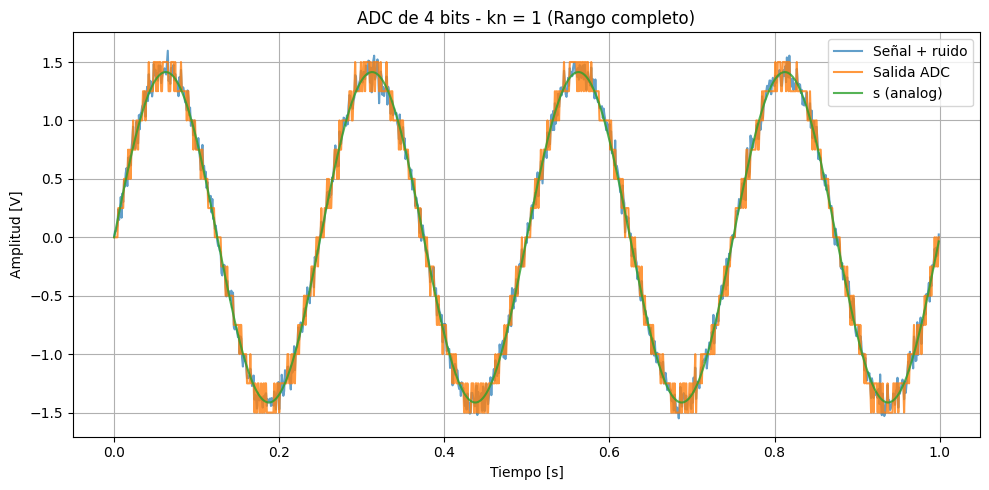

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(tt, sr, label="Señal + ruido", alpha=0.7)
plt.plot(tt, sr_q, label="Salida ADC", alpha=0.8)
plt.plot(tt, s, label="s (analog)", alpha=0.8)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("ADC de 4 bits - kn = 1 (Rango completo)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

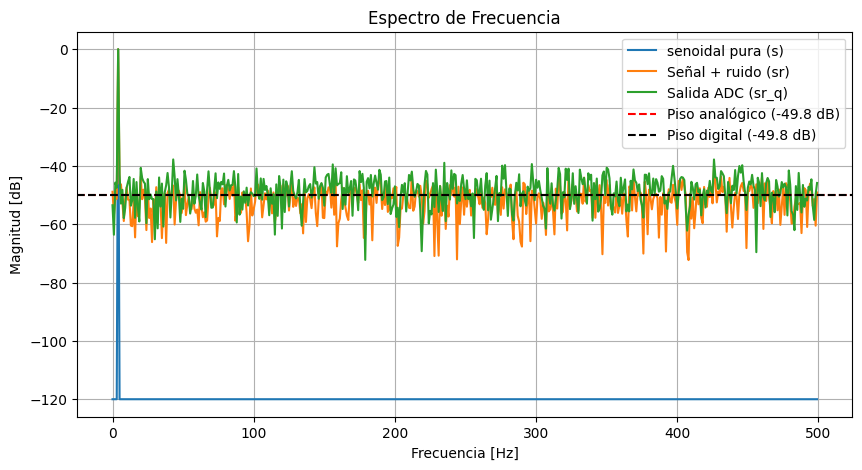

In [6]:
frec= np.arange(0,N)*delta_f
S= 1/N *np.fft.fft(s)
SR_q= 1/N *np.fft.fft(sr_q)
SR= 1/N *np.fft.fft(sr)

S    = 10 * np.log10(2*np.abs(S[:N // 2])**2    + 1e-12)
SR   = 10 * np.log10(2*np.abs(SR[:N // 2])**2   + 1e-12)
SR_q = 10 * np.log10(2*np.abs(SR_q[:N // 2])**2 + 1e-12)

# Error de cuantización (te faltaba definirlo)
nq = sr_q - sr

# Pisos de ruido teóricos (te faltaba definirlos)
piso_analogico = 10 * np.log10(2 * Pn / N + 1e-12)
piso_digital   = 10 * np.log10(2 * Pq / N + 1e-12)
# --- Gráfico 1: espectro ---
plt.figure(figsize=(10, 5))
plt.plot(frec[:N // 2], S, label="senoidal pura (s)")
plt.plot(frec[:N // 2], SR, label="Señal + ruido (sr)")
plt.plot(frec[:N // 2], SR_q, label="Salida ADC (sr_q)")
plt.axhline(piso_analogico, color="red", linestyle="--", label=f"Piso analógico ({piso_analogico:.1f} dB)")
plt.axhline(piso_digital, color="black", linestyle="--", label=f"Piso digital ({piso_digital:.1f} dB)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Espectro de Frecuencia")
plt.grid(True)
plt.legend()
plt.show()

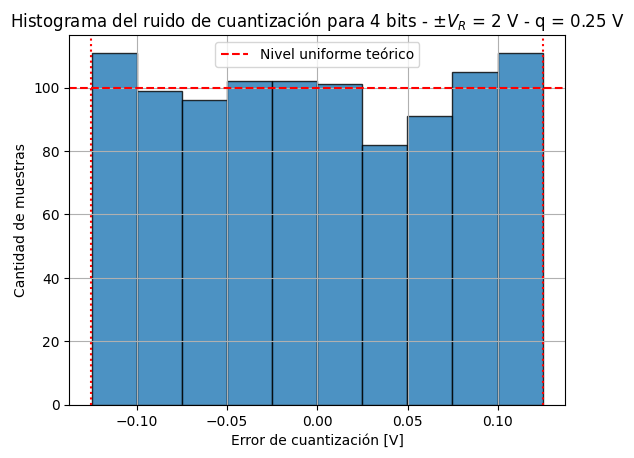

In [7]:
plt.figure()
n_bins = 10
conteo, bordes, _ = plt.hist(nq, bins=n_bins, edgecolor='black', alpha=0.8)

# Línea teórica: distribución uniforme entre -q/2 y q/2
altura_teorica = len(nq) / n_bins  # altura esperada si fuera perfectamente uniforme
plt.axhline(altura_teorica, color="red", linestyle="--", label=f"Nivel uniforme teórico")
plt.axvline(-qq/2, color="red", linestyle=":")
plt.axvline(qq/2, color="red", linestyle=":")

plt.xlabel("Error de cuantización [V]")
plt.ylabel("Cantidad de muestras")
plt.title(f"Histograma del ruido de cuantización para {B} bits - $\\pm V_R$ = {VF} V - q = {qq} V")
plt.legend()
plt.grid(True)
plt.show()

## 2.2  b) Analizar para una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, kn={1/10,1,10}


## 3.1. Análisis y Discusión de Resultados

### 3.1.1. Configuración $B = 4\text{ bits}, k_n = 10$ (Canal Dominado por Ruido Analógico)

![Dominio del Tiempo B4](b4k10tiempo.png)
![Espectro FFT B4](b4k10especto.png)
![Histograma Error B4](b4k10.png)

* **Dominio del Tiempo:** La señal $s_r(t)$ exhibe fluctuaciones aleatorias prominentes sobre la onda senoidal debido a la alta potencia de ruido analógico ($P_n = 10 \cdot P_q$). La salida del ADC ($s_{rq}$) sigue la tendencia pero presenta un escalonamiento muy marcado producto del paso de cuantización grueso ($q = 0.2500\text{ V}$).
* **Espectro de Frecuencia:** El piso de ruido analógico se ubica en **$-39.8\text{ dB}$**, quedando significativamente por encima del piso de cuantización digital (**$-49.8\text{ dB}$**). 
  * *Discusión:* El sistema opera **limitado por el ruido del canal**. Aumentar la resolución del ADC bajo estas condiciones no aporta ninguna mejora efectiva en la relación señal a ruido total, ya que la incertidumbre de la entrada domina el espectro.
* **Histograma del Error:** La diferencia $e(t) = s_{rq}(t) - s_r(t)$ se distribuye de manera uniforme dentro del rango $[-\frac{q}{2}, \frac{q}{2}] = [-0.125\text{ V}, 0.125\text{ V}]$.

---

### 3.1.2. Configuración $B = 8\text{ bits}, k_n = 1$ (Balance Analógico/Digital)

![Dominio del Tiempo B8](tiempob8k1.png)
![Espectro FFT B8](espectrob8k1.png)
![Histograma Error B8](histogramab8k1.png)

* **Dominio del Tiempo:** Al incrementar la resolución a 8 bits ($256$ niveles), el paso de cuantización disminuye a $q = 0.0156\text{ V}$. La salida digitalizada se ajusta estrechamente a la señal senoidal ruidosa sin distorsión visible de escalón.
* **Espectro de Frecuencia:** El piso analógico y el piso de cuantización digital coinciden perfectamente en **$-73.9\text{ dB}$**.
  * *Discusión:* En comparación con el caso de 4 bits con $k_n=1$, la atenuación del piso de ruido total experimenta un descenso de aproximadamente **$24\text{ dB}$**. Este resultado valida empíricamente la regla de Holton de los **$6.02\text{ dB}$ por bit adicional** ($\Delta B = 4 \implies 4 \times 6.02 \approx 24.08\text{ dB}$). Representa el punto de diseño óptimo donde ningún tipo de ruido penaliza innecesariamente al otro.
* **Histograma del Error:** Mantiene la uniformidad estadística contenida en el intervalo $[-\frac{q}{2}, \frac{q}{2}] = [-0.0078\text{ V}, 0.0078\text{ V}]$.

---

### 3.1.3. Configuración $B = 16\text{ bits}, k_n = 0.1$ (Cuantización de Alta Precisión)

![Dominio del Tiempo B16](tiempob16k01.png)
![Espectro FFT B16](espectrob16k01.png)
![Histograma Error B16](b16k01histo.png)

* **Dominio del Tiempo:** Con $65536$ niveles disponibles, el paso se reduce a un valor de $q = 0.0001\text{ V}$ ($0.1\text{ mV}$). A escala completa, la traza de la señal reconstruida por el ADC es visualmente indistinguible de la función senoidal de entrada.
* **Espectro de Frecuencia:** El piso analógico se ubica en **$-119.7\text{ dB}$** mientras que el piso digital se posiciona en **$-117.9\text{ dB}$**.
  * *Discusión:* Al ser $k_n = 0.1$, el ruido analógico representa una fracción despreciable frente a la SQNR del conversor. El sistema aprovecha casi en su totalidad el rango dinámico teórico de 16 bits, operando en un régimen de cuantización de alta fidelidad.
* **Histograma del Error:** El error permanece confinado dentro de los límites teóricos del escalón $[-\frac{q}{2}, \frac{q}{2}] = [-3.05 \times 10^{-5}\text{ V}, 3.05 \times 10^{-5}\text{ V}]$.

---

### Cuadro Comparativo de Resultados

| Parámetro | $B = 4\text{ bits}, k_n = 10$ | $B = 8\text{ bits}, k_n = 1$ | $B = 16\text{ bits}, k_n = 0.1$ |
| :--- | :---: | :---: | :---: |
| **Paso $q$ [V]** | $0.2500$ | $0.0156$ | $0.0001$ |
| **Piso Analógico [dB]** | $-39.8$ | $-73.9$ | $-119.7$ |
| **Piso Digital [dB]** | $-49.8$ | $-73.9$ | $-117.9$ |
| **Limitante Principal** | Ruido del Canal | Equilibrado | Resolución del ADC |

##  4 Conclusiones

* **Trade-off entre Ruido Analógico y Resolución Digital:** Aumentar indiscriminadamente la resolución en bits ($B$) del ADC no garantiza una mejora en la calidad de la señal digitalizada si el canal o la etapa analógica previa están dominados por el ruido. Si $P_n \gg P_q$ (como en el caso $B=4, k_n=10$), el piso de ruido total queda fijado por el canal analógico, volviendo inútil el gasto computacional o de hardware de un conversor de más bits.
* **Punto de Diseño Óptimo ($k_n \approx 1$):** El escenario $B=8, k_n=1$ demuestra la condición ideal de dimensionamiento de un sistema de adquisición de datos. Los pisos de ruido analógico y de cuantización coinciden ($-73.9\text{ dB}$), aprovechando al máximo la resolución del conversor sin desperdiciar capacidad de procesamiento ni sufrir degradación severa por el canal.
